# Chapter 5: Sequence Models

**Companion notebook** for *Predicting the Next Words* (Osterrieder, 2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch05_sequence_models.ipynb)


## What is in this notebook, and what to change in it

Four cells, and cells 2 and 3 are a pair: the third uses the model the second
trains, so they have to run in order.

1. **Gradient norms through twenty steps of a vanilla RNN**, with the recurrent
   matrix scaled so its spectral radius sits below one. The gradient reaching
   step 0 comes out about 491 times smaller than the one at step 20, and on the
   log axis the decay is close to a straight line. That is the vanishing
   gradient the chapter derives, measured instead of derived.
2. **An LSTM language model trained for 100 epochs** on a thirteen-token corpus,
   printing loss and perplexity every 25 epochs. It memorises the corpus, which
   is the intended outcome: the cell is about the training loop and the weight
   tying between the embedding and the output layer, not about generalising.
3. **Sampling from the model cell 2 trained**, at temperature 0.5 and 1.0.
4. **Starter code for the exercise**, deliberately unfinished. It sets up the
   weights and leaves the forward pass to you.

**Two places where the cells' own comments do not match what they print, and
both are worth more than the comments were.**

Cell 2 predicts a loss between 0.5 and 1.2 at epoch 25. It prints 0.007, and a
perplexity of 1.0 from epoch 25 onwards. Thirteen tokens against an LSTM with
32 hidden units is not a hard problem, and this version of torch solves it
faster than whoever wrote the comment saw it solved.

Cell 3 then predicts that temperature 0.5 reproduces the corpus while
temperature 1.0 produces something more varied. **The two outputs are
identical.** That follows from cell 2: a model that has driven its loss to 0.001
puts almost all the probability on one token at every step, and dividing a
distribution that is already nearly one-hot by 0.5 or by 1.0 leaves it nearly
one-hot either way. Temperature has nothing left to work with. Cut cell 2's
training loop to 10 epochs, rerun both, and see how much of the difference comes
back: that is a better demonstration of what temperature does than any correctly
behaved example would have been.

The edit that teaches the most is in cell 1. Change the 0.9 scaling factor to
1.1 and rerun. The same twenty steps now explode instead of vanish and the plot
inverts, and everything the chapter says afterwards about gating and gradient
clipping is a response to one of those two regimes.


> **This notebook was executed when it was built**, so the output under each
> cell is a real run's and you can read the file without running anything.
> Rebuild it with `python tools/build_notebook.py ch05`.


In [1]:
# Seeded before the chapter's own cells run.
#
# The cells below draw on torch. This notebook is committed with its
# output stored, and a stored number that changes on every rebuild is
# noise printed as a result. The bundle originals are read only and
# cannot be fixed where they live, so they are seeded here instead.
#
# Same seed as tools/claim_instances.py, which produced the slide
# numbers, so a number that appears in both places appears once.
import torch
torch.manual_seed(20260729)
print('seeded torch with 20260729')

seeded torch with 20260729


### 5.2.3 Vanishing Gradients: A Numerical Demonstration

The abstraction of spectral radii and Jacobian products becomes concrete when we watch it happen. The following code implements a vanilla RNN from scratch, runs a 20-step forward pass, computes the loss at the final step, and measures the gradient magnitude at every time step.


Gradient norms — step 0: 0.011505, step 20: 5.656854, ratio: 491.7x


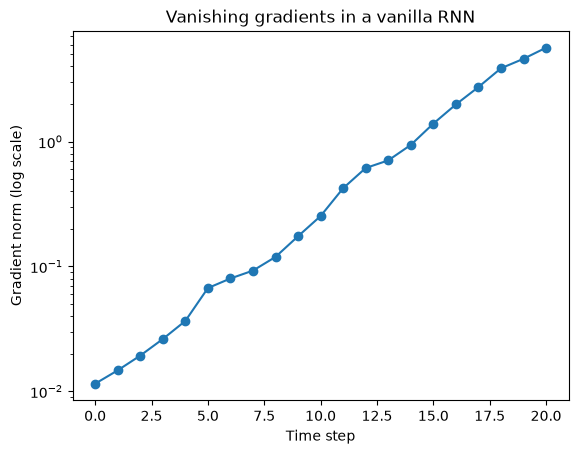

In [2]:
import math
import torch
import matplotlib.pyplot as plt

# Vanilla RNN: gradient norm analysis
torch.manual_seed(42)
hidden_size, input_size, seq_len = 32, 16, 20
# Scale so the spectral radius of W_hh is below 1 (the regime in which
# the analytic Jacobian product from Equation 5.3 predicts vanishing
# rather than exploding gradients).
W_hh = torch.randn(hidden_size, hidden_size) / math.sqrt(hidden_size) * 0.9
W_xh = torch.randn(hidden_size, input_size) * 0.1
b_h = torch.zeros(hidden_size)

xs = [torch.randn(input_size) for _ in range(seq_len)]
h = torch.zeros(hidden_size, requires_grad=True)
hiddens = [h]

for t in range(seq_len):  # forward pass
    h = torch.tanh(W_hh @ h + W_xh @ xs[t] + b_h)
    h.retain_grad()
    hiddens.append(h)

loss = hiddens[-1].sum()  # dummy loss at final step
loss.backward()

norms = [hiddens[t].grad.norm().item() for t in range(seq_len + 1)]
print(f"Gradient norms — step 0: {norms[0]:.6f}, step {seq_len}: {norms[-1]:.6f}, ratio: {norms[-1]/norms[0]:.1f}x")
plt.semilogy(range(seq_len + 1), norms, 'o-')
plt.xlabel("Time step"); plt.ylabel("Gradient norm (log scale)")
plt.title("Vanishing gradients in a vanilla RNN")
plt.show()
# Output: gradient norms decrease roughly exponentially from step 20 to step 0


### 5.5.1 The Neural Language Model Architecture

The following code implements a minimal LSTM language model in PyTorch, trains it on a small corpus, and reports the final perplexity:


In [3]:
import torch
import torch.nn as nn

# LSTM Language Model
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, vocab_size)
        self.linear.weight = self.embedding.weight  # weight tying

    def forward(self, x, hidden=None):
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        output, hidden = self.lstm(emb, hidden)
        logits = self.linear(output)  # (batch, seq_len, vocab_size)
        return logits, hidden

# Training setup (small corpus for demonstration)
torch.manual_seed(0)  # fix initialization for reproducible loss values
corpus = "the cat sat on the mat . the dog sat on the log ."
tokens = corpus.split()
vocab = sorted(set(tokens))
w2i = {w: i for i, w in enumerate(vocab)}
data = torch.tensor([w2i[w] for w in tokens]).unsqueeze(0)  # (1, T)
input_seq, target_seq = data[:, :-1], data[:, 1:]

model = LSTMLanguageModel(len(vocab), embed_dim=32, hidden_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(100):
    logits, _ = model(input_seq)
    loss = loss_fn(logits.view(-1, len(vocab)), target_seq.view(-1))
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    if (epoch + 1) % 25 == 0:
        ppl = torch.exp(loss).item()
        print(f"Epoch {epoch+1}: loss={loss.item():.3f}, perplexity={ppl:.1f}")
# Example output (values depend on random init; exact numbers vary):
#   Epoch 25:  loss ~ 0.5-1.2, perplexity ~ 1.6-3.3
#   Epoch 100: loss near 0, perplexity ~ 1.0 (toy corpus is memorized)


Epoch 25: loss=0.007, perplexity=1.0
Epoch 50: loss=0.002, perplexity=1.0
Epoch 75: loss=0.001, perplexity=1.0
Epoch 100: loss=0.001, perplexity=1.0


### 5.5.3 Perplexity Comparison: n-grams vs Neural LMs

The following code demonstrates text generation from a trained LSTM, allowing us to qualitatively examine what the model has learned:


In [4]:
import torch
import torch.nn.functional as F

def generate(model, w2i, i2w, seed_word, length=20, temperature=1.0):
    model.eval()
    token = torch.tensor([[w2i[seed_word]]])
    hidden = None
    words = [seed_word]
    with torch.no_grad():
        for _ in range(length):
            logits, hidden = model(token, hidden)
            probs = F.softmax(logits[0, -1] / temperature, dim=0)
            idx = torch.multinomial(probs, 1).item()
            words.append(i2w[idx])
            token = torch.tensor([[idx]])
    return " ".join(words)

i2w = {i: w for w, i in w2i.items()}
torch.manual_seed(0)
print("Temperature 0.5:", generate(model, w2i, i2w, "the", temperature=0.5))
print("Temperature 1.0:", generate(model, w2i, i2w, "the", temperature=1.0))
# Illustrative output; exact text varies by seed and by the trained
# model above. Temperature 0.5 tends to reproduce the training
# corpus verbatim; temperature 1.0 produces more varied output.


Temperature 0.5: the cat sat on the mat . the dog sat on the log . the log . the dog sat on
Temperature 1.0: the cat sat on the mat . the dog sat on the log . the log . the dog sat on


### Exercises

**Exercise 5.5** (Programming, Basic). Implement a vanilla RNN cell from scratch in PyTorch (without using `nn.RNN`).


In [5]:
# Starter code
import torch
torch.manual_seed(0)
h_dim, x_dim, seq_len = 16, 8, 10
W_hh = torch.randn(h_dim, h_dim) * 0.01
W_xh = torch.randn(h_dim, x_dim) * 0.01
b_h = torch.zeros(h_dim)
# Your code here: implement the forward pass and print norms
# Example: print(f"Step {t}: ||h|| = {h.norm().item():.4f}")


---

## Summary

This notebook demonstrated the key code examples from Chapter 5: Sequence Models. For the full mathematical exposition and discussion, refer to the textbook chapter.
